<a href="https://colab.research.google.com/github/mondalankit665-gif/ankit-Mondal/blob/main/minor_project2s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Sample Data Creation
data = {
    'Brand': ['Dell', 'HP', 'Apple', 'Lenovo', 'Asus', 'Dell', 'Apple', 'HP', 'Lenovo', 'Asus'],
    'Processor': ['i5', 'i7', 'M1', 'i5', 'Ryzen 5', 'i7', 'M2', 'i3', 'Ryzen 7', 'i5'],
    'RAM': [8, 16, 8, 8, 16, 32, 16, 4, 16, 8],
    'Price': [600, 900, 1200, 550, 750, 1500, 1800, 400, 850, 650]
}
df = pd.DataFrame(data)

# 2. Features and Target
X = df.drop('Price', axis=1)
y = df['Price']

# 3. Preprocessing and Modeling Pipeline
# FIX: Added handle_unknown='ignore' to deal with categories not seen during training
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [0, 1])
], remainder='passthrough')

step2 = LinearRegression()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model Training
pipe.fit(X_train, y_train)

# 6. Evaluation
y_pred = pipe.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")

# Example Prediction
# Sample input: Dell, i7, 16GB RAM
query = np.array([['Dell', 'i7', 16]])
prediction = pipe.predict(pd.DataFrame(query, columns=['Brand', 'Processor', 'RAM']))
print(f"\nPredicted Price: ${prediction[0]:.2f}")

R2 Score: -0.06911837424170542
MAE: 18.43762495002136

Predicted Price: $885.21


## 1. Data Visualization
Visualizing the relationship between RAM, Brand, and Price to understand patterns.

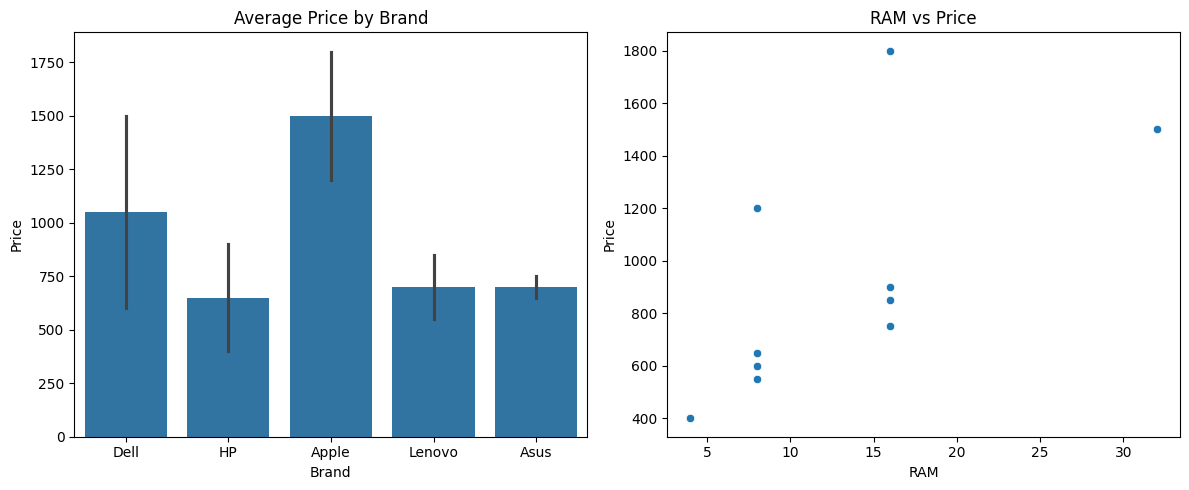

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Brand', y='Price', data=df)
plt.title('Average Price by Brand')

plt.subplot(1, 2, 2)
sns.scatterplot(x='RAM', y='Price', data=df)
plt.title('RAM vs Price')

plt.tight_layout()
plt.show()

## 2. Advanced Modeling
Comparing Linear Regression with a Random Forest Regressor, which often handles categorical features and non-linear relationships better.

In [5]:
from sklearn.ensemble import RandomForestRegressor

# Define a Random Forest Pipeline
rf_step2 = RandomForestRegressor(n_estimators=100, random_state=42)

rf_pipe = Pipeline([
    ('step1', step1),
    ('step2', rf_step2)
])

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)

print(f"Random Forest R2 Score: {r2_score(y_test, rf_pred)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred)}")

Random Forest R2 Score: -31.149
Random Forest MAE: 141.75


## 3. Flask Web App Structure
To build a web app, you would typically save the model using `pickle` and create a `app.py` file. Below is the structure.

In [6]:
import pickle

# Save the model pipeline
with open('laptop_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

# Flask App Code (To be run in a local environment)
flask_code = """
from flask import Flask, render_template, request
import pickle
import pandas as pd
import numpy as np

app = Flask(__name__)
model = pickle.load(open('laptop_model.pkl', 'rb'))

@app.route('/')
def index():
    return "Laptop Price Predictor API is Running"

@app.route('/predict', methods=['POST'])
def predict():
    brand = request.form.get('brand')
    processor = request.form.get('processor')
    ram = int(request.form.get('ram'))

    query = pd.DataFrame([[brand, processor, ram]], columns=['Brand', 'Processor', 'RAM'])
    result = model.predict(query)[0]
    return str(round(result, 2))

if __name__ == '__main__':
    app.run(debug=True)
"""

print("Model saved as 'laptop_model.pkl'. You can now use the Flask structure provided above.")

Model saved as 'laptop_model.pkl'. You can now use the Flask structure provided above.
